In [1]:
from sklearn import datasets
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [2]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [3]:
Gamma_data = dict(zip(names,data))
data_flux = np.array(Gamma_data['T90'],dtype='float')

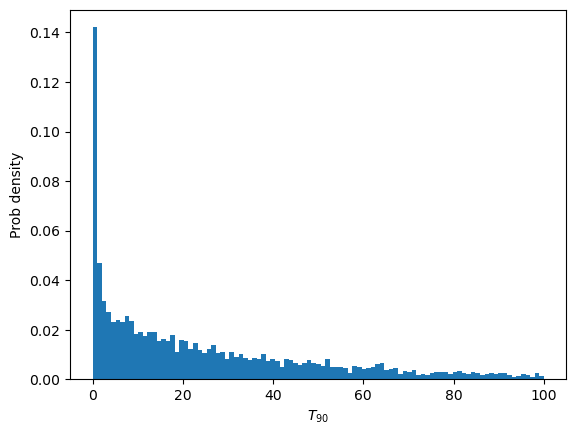

In [4]:
plt.hist(data_flux, bins= np.linspace(0,100,100), density=True)
plt.xlabel(r'$T_{90}$')
plt.ylabel('Prob density');

C:\Users\kevin\AppData\Local\Temp\ipykernel_19476\2756229222.py:1: RuntimeWarning: invalid value encountered in log10
  plt.hist(np.log10(data_flux), bins= np.linspace(-3,3,100), density=True)


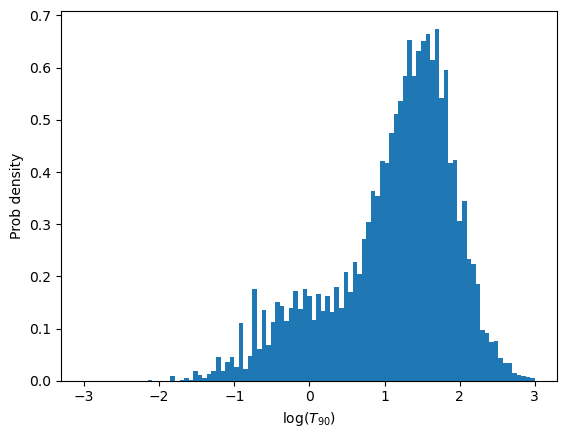

In [5]:
plt.hist(np.log10(data_flux), bins= np.linspace(-3,3,100), density=True)
plt.xlabel(r'log($T_{90}$)')
plt.ylabel('Prob density');

In [6]:
#seems to be that there is 2 differents populations, lets see

In [7]:
data_flux_log=np.log10(data_flux)
data_flux_log=data_flux_log[~np.isnan(data_flux_log)] #in roder to remove the conflictive data
data_fluxSK = data_flux_log[:,np.newaxis]

C:\Users\kevin\AppData\Local\Temp\ipykernel_19476\1462119271.py:1: RuntimeWarning: invalid value encountered in log10
  data_flux_log=np.log10(data_flux)


In [8]:
from sklearn.cluster import KMeans
from sklearn import preprocessing

clf = KMeans(n_clusters=2,n_init='auto')
clf.fit(data_fluxSK)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(data_fluxSK) #labels for each of the points, a que clase pertenece??

In [9]:
centers=10**np.squeeze(centers) #regresas de log a normal para ver el verdadero center.

if centers[0] > centers[1]:
    centers = centers[::-1]  
    labels = 1 - labels

edge = 10**( np.mean( [max(data_flux_log[labels==0]), min(data_flux_log[labels==1]) ]))
# esto me dice, mira si tu centro 1 en relaidad esta mas lejos del 2, entonces haz el cambio de los lables, poque no qeuire sllamar 1 al que esta mas lejos y 2 al que esta as cerca, entonces solo haces un re orden

[ 0.91858803 33.15050437]
5.511994194481702


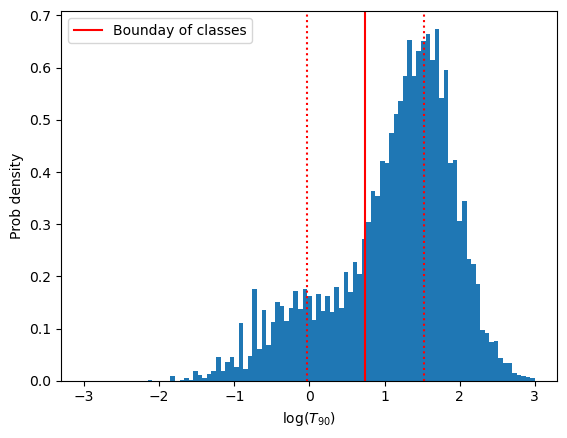

In [10]:
plt.hist(data_flux_log, bins= np.linspace(-3,3,100), density=True);
for i in centers:
    plt.axvline(np.log10(i), c='red',ls='dotted')
plt.axvline(np.log10(edge),c='red', label='Bounday of classes')
plt.legend()
plt.xlabel(r'log($T_{90}$)')
plt.ylabel('Prob density')
print(centers)
print(edge);

In [11]:
#it is 2 clusters the best? lets do crosos validation

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, silhouette_score
from sklearn.base import BaseEstimator, ClusterMixin
import warnings

warnings.filterwarnings("ignore")

def silhouette_scorer_unsupervised(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

n_clusters = [1, 2, 3, 4]
K = 5

grid = GridSearchCV(KMeans(n_init='auto', random_state=42), param_grid={'n_clusters': n_clusters}, scoring=silhouette_scorer_unsupervised, cv=K)

grid.fit(data_fluxSK)

print("the best numbers of clusters is", grid.best_params_['n_clusters']) #all ok

the best numbers of clusters is 2


In [14]:
#lets try fit with gaussian mixture
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix

gmm = GaussianMixture(2).fit(data_fluxSK)
means = 10**np.squeeze(gmm.means_)
responsibilities = gmm.predict_proba(data_fluxSK)

if means[0]>means[1]:
    means=means[::-1]
    responsibilities= responsibilities[:,::-1]

#responsibilities represent just a prob of belongs to any class then you just chosee the most prob for clustering

gmmoutcome = np.array(responsibilities[:,0]<responsibilities[:,1],dtype='int') #estos serian los labels que hace este modelo

In [15]:
confusion_matrix(gmmoutcome,labels) #con resepcto al otro metodo, recordar que este es un metodo no supervisado.

array([[1693,    0],
       [ 282, 5684]], dtype=int64)

[ 0.97301447 30.63111007]


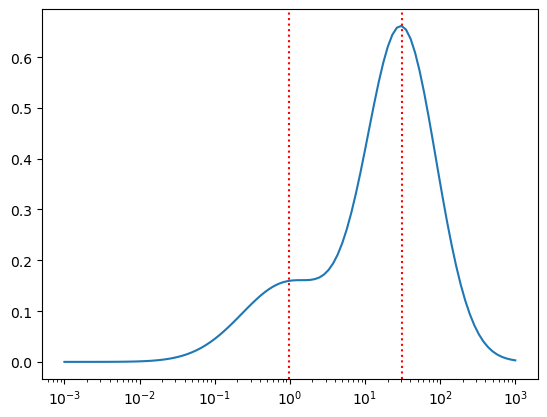

In [16]:
xgrid=np.logspace(-3,3,100)
ygmm = np.exp(gmm.score_samples( np.log10(xgrid)[:,np.newaxis] ))

plt.plot(xgrid,ygmm)

for v in means:
    plt.axvline(v, c='red',ls='dotted')
plt.semilogx();

print(means)

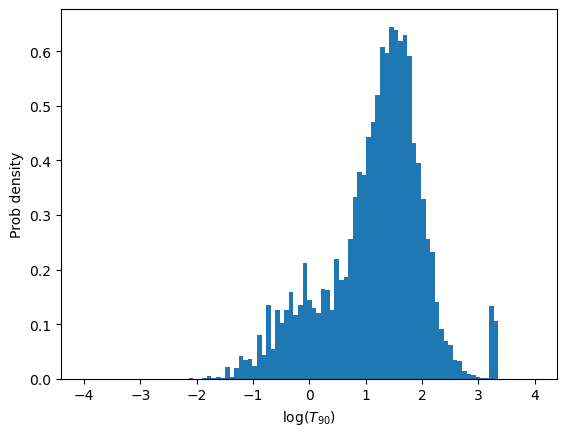

In [17]:
#bueno aqui tienes los centros de los 2 modelos gaussianos que has obtenido con este nuevo metodo , ojo no es el cento de los cluster, pero de las gaussianas, por eos es que son 2 diferentes metodos.
#How do methods respond to outliers?

num_outliers = 300

mean = np.mean(data_flux)
std = np.std(data_flux)

outliers_high = mean + 5 * std + np.random.rand(num_outliers // 2) * std
outliers_low = mean - 5 * std - np.random.rand(num_outliers // 2) * std

data_flux_with_outliers = np.concatenate([data_flux, outliers_high, outliers_low])
plt.hist(np.log10(data_flux_with_outliers), bins= np.linspace(-4,4,100), density=True)
plt.xlabel(r'log($T_{90}$)')
plt.ylabel('Prob density');

[ 1.0126031  38.06575346]
6.233945780964093


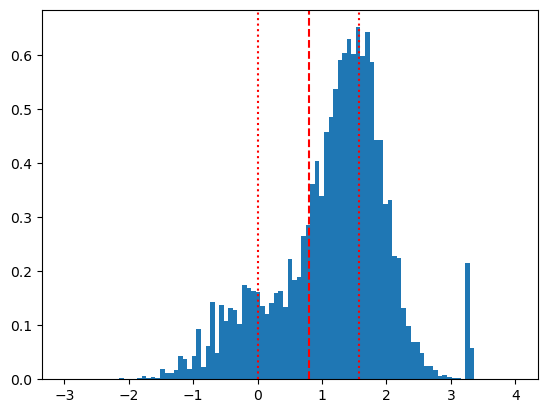

In [18]:
#lets see the diferences now without the outlayers.
data_outliersSK_log=np.log10(data_flux_with_outliers)
data_outliersSK_log=data_outliersSK_log[~np.isnan(data_outliersSK_log)] #in roder to remove the conflictive data
data_outliersSK = data_outliersSK_log[:,np.newaxis]
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(data_outliersSK)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(data_outliersSK) #labels for each of the points, a que clase pertenece??

centers=10**np.squeeze(centers) #regresas de log a normal para ver el verdadero center.

if centers[0]>centers[1]:
    centers=centers[::-1] # Reverse array
    labels = np.array(~np.array(labels,dtype='bool'),dtype='int') # Swap 0 <--> 1

edge = 10**( np.mean( [max(data_outliersSK_log[labels==0]), min(data_outliersSK_log[labels==1]) ]))

plt.hist(data_outliersSK_log, bins= np.linspace(-3,4,100), density=True);
for v in centers:
    plt.axvline(np.log10(v), c='red',ls='dotted')
plt.axvline(np.log10(edge),c='red',ls='dashed');

print(centers)
print(edge)

#seems to eb really sensible for this especific outliers.... bc the nwe center is not there anymore, ask thisss. pls

[ 0.9482053  32.10285929]


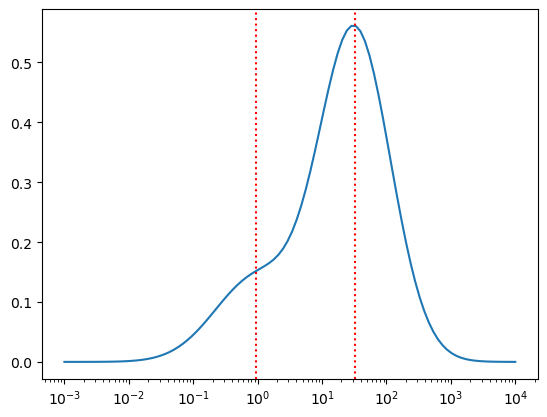

In [19]:
#how does respond with GMM

gmm = GaussianMixture(2).fit(data_outliersSK)
means = 10**np.squeeze(gmm.means_)
responsibilities = gmm.predict_proba(data_outliersSK)

if means[0]>means[1]:
    means=means[::-1]
    responsibilities= responsibilities[:,::-1]

gmmoutcome = np.array(responsibilities[:,0]<responsibilities[:,1],dtype='int') #estos serian los labels que hace este modelo

xgrid=np.logspace(-3,4,100)
ygmm = np.exp(gmm.score_samples( np.log10(xgrid)[:,np.newaxis] ))

plt.plot(xgrid,ygmm)

for v in means:
    plt.axvline(v, c='red',ls='dotted')
plt.semilogx();

print(means)

In [20]:
#What variable shows the multi-modality more evidently?

redshift = np.array(Gamma_data['redshift'],dtype='float')

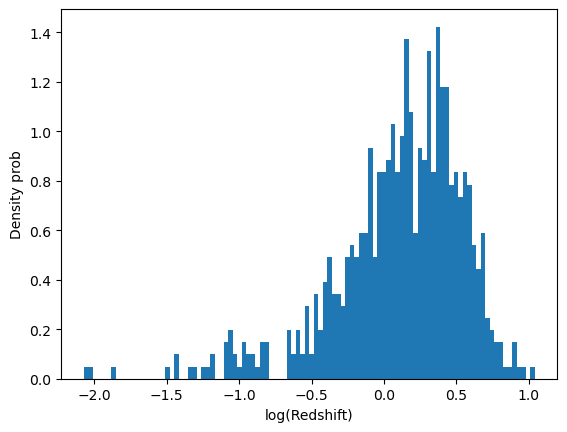

In [21]:
plt.hist(np.log10(redshift), bins=100, density=True)
plt.xlabel('log(Redshift)')
plt.ylabel('Density prob'); #seems to have also more than one modility si ok ), idk if there is any others data with that beheavor

In [22]:
redshift_log=np.log10(redshift)
redshift_log=redshift_log[~np.isnan(redshift_log)] #in roder to remove the conflictive data
redshiftSK = redshift_log[:,np.newaxis]

In [26]:
warnings.filterwarnings("ignore")

n_clusters = [1, 2, 3, 4]
K = 8

grid = GridSearchCV(KMeans(n_init='auto', random_state=42), param_grid={'n_clusters': n_clusters}, scoring=silhouette_scorer_unsupervised, cv=K)

grid.fit(redshiftSK)

print("the best numbers of clusters is", grid.best_params_['n_clusters']) #all ok

the best numbers of clusters is 3


[0.87287692 2.85981213 0.11656812]
1.5834140330311588


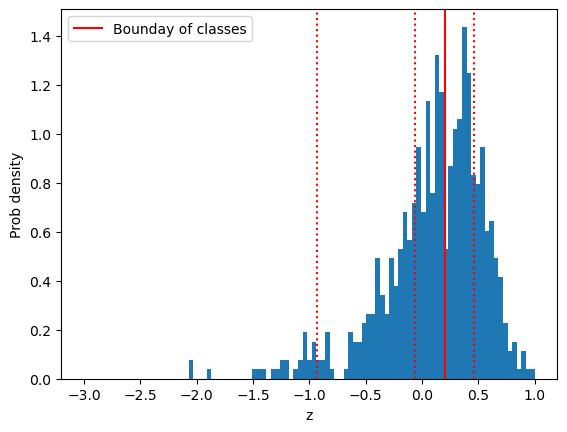

In [123]:
clf = KMeans(n_clusters=3,n_init='auto')
clf.fit(redshiftSK)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(redshiftSK) #labels for each of the points, a que clase pertenece??

centers=10**np.squeeze(centers) #regresas de log a normal para ver el verdadero center.

if centers[0] > centers[1]:
    centers = centers[::-1]  
    labels = 1 - labels

edge = 10**( np.mean( [max(redshift_log[labels==0]), min(redshift_log[labels==1]) ]))

plt.hist(redshift_log, bins= np.linspace(-3,1,100), density=True);
for i in centers:
    plt.axvline(np.log10(i), c='red',ls='dotted')
plt.axvline(np.log10(edge),c='red', label='Bounday of classes')
plt.legend()
plt.xlabel(r'z')
plt.ylabel('Prob density')
print(centers)
print(edge);

In [68]:
# are all GBRs equaly to be observed??